# Windstorm tracks and footprints derived from reanalysis over Europe between 1940 to present: Algorithm comparison

Production date: 2026-MM-DD

**Please note that this repository is used for development and review, so quality assessments should be considered work in progress until they are merged into the main branch.**

Produced by: Enis Gerxhalija & Olivier Burggraaff (National Physical Laboratory).

## 🌍 Use case: Use case listed here in full 

## ❓ Quality assessment question
* **How do the TempestExtremes (MSLP) and Hodges (vorticity) tracking algorithms differ in their detection of extratropical cyclones, particularly in terms of their sensitivity, duration, and intensity?**
* **How do windstorms in matchups between the TempestExtremes (MSLP) and Hodges (vorticity) tracking algorithms differ in their duration and intensity when compared to the dataset?**

**‘Context paragraph’ (no title/heading)** - a very short introduction before the assessment statement describing approach taken to answer the user question. One or two key references could be useful, if the assessment summarises literature.

**Background**

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
* Finding 1
* Finding 2
* Finding 3
* etc
```

## 📋 Methodology

**Note:** This notebook is currently just a brain-dump in anticipation of starting the actual quality assessment at a later stage.

**Summary**  

The analysis and results are organised in the following steps, which are detailed in the sections below:

**[](section-setup)**

**[](section-download)**

**[](section-sensitivity)**

**[](section-duration)**

**[](section-intensity)**

**[](section-matchups)**

Any further notes on the method could go here (explanations, caveats or limitations).

## 📈 Analysis and results

(section-setup)=
### 1. Code setup
```{note}
This notebook uses [earthkit](https://github.com/ecmwf/earthkit) for
downloading ([earthkit-data](https://github.com/ecmwf/earthkit-data))
and visualising ([earthkit-plots](https://github.com/ecmwf/earthkit-plots)) data.
Because earthkit is in active development, some functionality may change after this notebook is published.
If any part of the code stops functioning, please raise an issue on our GitHub repository so it can be fixed.
```

#### Imports

In [32]:
# Input / Output
from pathlib import Path
import earthkit.data as ekd
import warnings

# General data handling
import numpy as np
np.seterr(divide="ignore")  # Ignore divide-by-zero warnings
import pandas as pd
import geopandas as gpd
from functools import partial, reduce
from operator import and_ as bitwise_and
from dask.array.core import PerformanceWarning
warnings.simplefilter(action="ignore", category=PerformanceWarning)

# Visualisation
import earthkit.plots as ekp
from earthkit.plots.styles import Style
import matplotlib.pyplot as plt
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["figure.constrained_layout.use"] = True
plt.rcParams["figure.labelweight"] = "bold"
plt.rcParams["figure.titleweight"] = "bold"
from matplotlib.colors import LogNorm
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.lines import Line2D
import cartopy
from cartopy import crs as ccrs
import shapely
from shapely.geometry import Polygon, MultiPolygon
import cmcrameri as cmc
from tqdm import tqdm  # Progress bars
import matplotlib.colors as mcolors
# Visualisation in Jupyter book -- automatically ignored otherwise
try:
    from myst_nb import glue
except ImportError:
    glue = None

# Type hints
from typing import Callable, Iterable, Optional
from cartopy.mpl.geoaxes import GeoAxes


#### Helper functions

##### Data (pre-)processing

The following cell contains some pre-defined constants for convenience,
such as a list of variable names in the data:

In [33]:
# Data
TRACKING_ALGORITHMS = ["hodges", "tempest_extremes"]
NUTS_LEVELS         = [0, 1, 2]

# Columns in data
SELECTION_COLUMNS   = ["algorithm", "threshold", "year",]
VARIABLES           = ["storms_number", "mean_wind_gust", "ssi", "normalised_ssi", "area_ratio", "wind_gust_ratio",]
NUTS_VARIABLES      = ["region", "country_code", "NUTS_level", "NUTS_name",]

# Organisation of data
INDEX_COLUMNS       = ["algorithm", "threshold", "region", "year",]

The following functions select data from a (Geo)DataFrame according to one or multiple conditions,
e.g. a specific year and tracking algorithm:

In [34]:
def _select_from_column(df: pd.DataFrame, col: str, val) -> pd.Series:
    """
    Create a True/False mask for one column `col` in a (Geo)DataFrame `df`
    where the value is `val`.
    Checks for iterable/non-iterable values and switches between .isin and == accordingly.
    """
    # Check for single / multiple values
    if df[col].dtype == "O":  # String column
        if isinstance(val, str):
            # Value is str -> Single value
            iterable_val = False
        elif isinstance(val, Iterable):
            # Value is Iterable but not str -> assume Iterable[str]
            iterable_val = True
        else:
            raise ValueError(f"Cannot parse value of type `{type(val)}` for column `{col}`.")
    else:  # Non-string column, assume number or similar
        iterable_val = isinstance(val, Iterable)

    # Create True/False mask
    selection = (df[col].isin(val)) if iterable_val else (df[col] == val)
    return selection

def select_data(df: pd.DataFrame, **kwargs):
    """
    Select data from a given (Geo)DataFrame `df` according to any number of conditions,
    matching its column names.
    """
    # Create masks for all col/val pairs in kwargs, then combine with & (bitwise and)
    selection_all = [_select_from_column(df, col, val) for col, val in kwargs.items()]
    selection = reduce(bitwise_and, selection_all)

    # Apply and return
    df_selection = df[selection]
    return df_selection

The following functions allow large amounts of data to be downloaded from CDS, and to send requests based on track information.

In [35]:
# Handling CDS size limits
def batch_requests(main_request: dict, *, batch_key: str="year", n: int=20) -> list[dict]:
    """ Take a big request (e.g. ERA5–Drought for all years) and separate it into smaller ones (size `n`). """
    from itertools import batched
    full_range = main_request[batch_key]  # e.g. [1940, 1941, ..., 2024]
    batched_range = batched(full_range, n)  # e.g. [1940, ..., 1959], [1960, ..., 1979], ...
    subrequests = [main_request | {batch_key: batch} for batch in batched_range]  # create corresponding CDS requests
    return subrequests
    
def build_era5msl_request_from_time(time_value):
    """
    Create a CDS API request for ERA5 MSLP for the given date.
    Always retrieves the 4 synoptic times.
    """
    
    # Ensure datetime
    time_value = pd.to_datetime(time_value)

    year = f"{time_value.year}"
    month = f"{time_value.month:02d}"
    day = f"{time_value.day:02d}"

    request = {
        "product_type": ["reanalysis"],
        "variable": ["mean_sea_level_pressure"],
        "year": [year],
        "month": [month],
        "day": [day],
        "time": ["00:00", "06:00", "12:00", "18:00"],
        "data_format": "netcdf",
        "download_format": "unarchived",
        "area": [70, -80, 30, 35],  # windstorm track domain
    }

    return request

##### Visualisation

In [36]:
# Geometry / Projection
EPSG = 3035
CRS = cartopy.crs.epsg(EPSG)
MAP_KWARGS={"projection": CRS,
            "xlim": (0.25e7, 0.74e7), "ylim": (1.3e6, 5.5e6),  # Continental Europe
           }

# Define styles for land, borders, etc.
STYLE_LAND            = {"zorder": 1, "facecolor": "#ccced1", "edgecolor": "none"}
STYLE_COASTLINE       = {"zorder": 3, "edgecolor": "black", "linewidth": 1}
STYLE_NATIONAL_BORDER = {"zorder": 3, "edgecolor": "black", "linewidth": 0.5}
STYLE_CHOROPLETH      = {"zorder": 2, "edgecolor": STYLE_NATIONAL_BORDER["edgecolor"], "linewidth": STYLE_NATIONAL_BORDER["linewidth"]/5}

In [37]:
_style_footprint = {"cmap": plt.cm.cividis, "vmin": 0, "vmax": 40}

styles = {
    "footprint": Style(**_style_footprint),
}

# Apply general settings
for style in styles.values():
    style.normalize = False

In [38]:
def _glue_or_show(fig: plt.Figure, glue_label: Optional[str]=None) -> None:
    """
    If `glue` is available, glue the figure using the provided label.
    If not, display the figure in the notebook.
    """
    try:
        glue(glue_label, fig, display=False)
    except TypeError:
        plt.show()
    finally:
        plt.close()

def _add_textbox_to_subplots(text: str, *axs: Iterable[plt.Axes | ekp.Subplot], right=False) -> None:
    """ Add a text box to each of the specified subplots. """
    # Get the plt.Axes for each ekp.Subplot
    axs = [subplot.ax if isinstance(subplot, ekp.Subplot) else subplot for subplot in axs]

    # Set up location
    x = 0.95 if right else 0.05
    horizontalalignment = "right" if right else "left"

    # Add the text
    for ax in axs:
        ax.text(x, 0.95, text, transform=ax.transAxes,
        horizontalalignment=horizontalalignment, verticalalignment="top",
        bbox={"facecolor": "white", "edgecolor": "black", "boxstyle": "round",
              "alpha": 1})

In [39]:
def decorate_fig(fig: ekp.Figure, *, title: Optional[str]="") -> None:
    """ Decorate an earthkit figure with land, coastlines, etc. """
    # Add progress bar because individual steps can be very slow for large plots
    with tqdm(total=4, desc="Decorating", leave=False) as progressbar:
        fig.land()
        progressbar.update()
        fig.coastlines()
        progressbar.update()
        # fig.borders()
        # progressbar.update()
        fig.gridlines(linestyle=plt.rcParams["grid.linestyle"])
        progressbar.update()
        fig.title(title)
        progressbar.update()

def decorate_fig(axs: Iterable[GeoAxes], *, title: Optional[str]="") -> None:
    """ Decorate a cartopy/matplotlib figure with land, coastlines, etc. """
    # Will be replaced by preceding (earthkit) function when earthkit-plots supports choropleth maps
    try:  # Ravel if numpy array
        axs = axs.ravel()
    except AttributeError:
        pass

    # Apply each decoration in order
    for ax in axs:
        ax.add_feature(cartopy.feature.LAND,      **STYLE_LAND)
        ax.add_feature(cartopy.feature.COASTLINE, **STYLE_COASTLINE)
        ax.add_feature(cartopy.feature.BORDERS,   **STYLE_NATIONAL_BORDER)

##### Plotting functions

In [40]:
DOMAIN = [-30, 50, 20, 85]

def plot_region_var_time(
    indic_data,
    region,
    algorithms=["hodges", "tempest_extremes"],
    threshold=None,
    nuts_level=None,
    variable="storms_number",
    title=None,
):

    # Colour mapping
    colors = {
        "hodges": "blue",
        "tempest_extremes": "red"
    }

    plt.figure(figsize=(8, 4))

    for algo in algorithms:

        nuts = indic_data.copy()

        # --- Filter ---
        nuts = nuts.xs(algo, level="algorithm")

        if threshold is not None:
            nuts = nuts.xs(threshold, level="threshold")

        if nuts_level is not None:
            nuts = nuts[nuts["NUTS_level"] == nuts_level]

        nuts = nuts.xs(region, level="region")

        # --- Plot ---
        plt.plot(
            nuts[variable],
            marker="o",
            linewidth=2,
            color=colors.get(algo, "black"),
            label=algo
        )

    plt.xlabel("Year")
    plt.ylabel(variable.replace("_", " ").title())

    if title is None:
        title = f"{region} for threshold > {threshold} ms^-1"

    plt.ylim([0, 50])
    plt.title(title)
    plt.grid(True)
    plt.legend()

    plt.show()


def plot_storm_counts_time_comparison(yearly_nuts_mean, title = "Storm Count Comparison (averaged over NUTS0)"):
    
    # Get available thresholds
    thresholds = yearly_nuts_mean[0].index.get_level_values("threshold").unique()

    fig, axes = plt.subplots(2, 2, sharex=True)
    axes = axes.ravel()  
    
    for ax, thr in zip(axes, thresholds):
        df = yearly_nuts_mean[0]["storms_number"]
        
        # Extract time series
        hodges = df.loc["hodges", thr]
        tempest = df.loc["tempest_extremes", thr]
        
        # Plot
        hodges.plot(ax=ax, label="Hodges", linewidth=2, color = "blue")
        tempest.plot(ax=ax, label="TempestExtremes", linewidth=2, color = "red")
        
        # Styling
        ax.set_title(f"Threshold = {thr} ms^-1")
        ax.set_ylabel("Storm count")
        ax.grid(True, alpha=0.3)
        ax.legend()

    # Shared x-axis label
    axes[-1].set_xlabel("Year")

    plt.suptitle(title, fontsize=14)
    plt.show()

def plot_storm_count_comparison(
    indic_data,
    year,
    algorithm=None,
    threshold=None,
    nuts_level=None,
    label="Storm count",
    title=None,
    vmin=0,
    vmax=20,
    cmap="viridis",
    chart=None, 
    show=True,    
):
    nuts = indic_data.copy()
    nuts = nuts.to_crs("EPSG:4326")
    nuts = nuts.xs(year, level="year")

    if algorithm is not None:
        nuts = nuts.xs(algorithm, level="algorithm")
    if threshold is not None:
        nuts = nuts.xs(threshold, level="threshold")
    if nuts_level is not None:
        nuts = nuts[nuts["NUTS_level"] == nuts_level]

    if title is None:
        title = f"{algorithm}"

    if chart is None:
        chart = ekp.Map(domain=DOMAIN, crs=ccrs.PlateCarree())

    ax = chart.ax
    bounds = list(range(0, 21, 1))
    norm = mcolors.BoundaryNorm(bounds, ncolors=plt.get_cmap(cmap).N)

    nuts.plot(
        column="storms_number",
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        legend=True,
        edgecolor="black",
        linewidth=0.3,
        vmin=vmin,
        vmax=vmax,
        legend_kwds={"label": label},
    )
    
    chart.coastlines()
    chart.borders()
    ax.set_title(title)

    if show:
        chart.show()

    return chart

def plot_lifetime_distribution(
    data,
    labels,
    colors,
    bins=np.arange(0, 50, 1),
    sigma=1
):

    plt.figure()

    count = 0 
    
    for df, label in zip(data, labels):

        df = df.copy()

        # Lifetime (hours)
        lifetime = (df["end_time"] - df["start_time"]).dt.total_seconds() / (60*60)

        # Histogram
        hist, bin_edges = np.histogram(lifetime, bins=bins, density=True)

        # Bin centres
        centres = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Plot
        plt.plot(centres, hist, label=label, color = colors[count])

        count += 1 
    # Labels and styling
    plt.xlabel("Lifetime (hours)")
    plt.ylabel("Probability density")
    plt.title("Cyclone Lifetime Distribution")
    plt.grid(True)
    plt.legend()

    plt.show()

def plot_tracks(data, id1 = None, id2 = None, tracker1="hodges", tracker2="tempest_extremes"):

    chart = ekp.Map(domain=DOMAIN, crs=ccrs.PlateCarree())
    
    msl_style = ekp.styles.Style(
        colors="RdBu_r",
        levels=range(980, 1030, 4),
        units="hPa",
        extend="both",
    )
    track_style = ekp.styles.Style(
        colors="magma",
        levels=range(0, 30, 2),
        units="ms-1",
        extend="max",
    )

    # --- Extract & sort data ---
    data_sorted = data.sort_index()
    
    df1, df2 = None, None

    # --- Try loading each track independently ---
    try:
        df1 = data_sorted.loc[tracker1, id1].sort_values("time").reset_index(drop=True)
    except KeyError:
        print(f"{tracker1} track not found")

    try:
        df2 = data_sorted.loc[tracker2, id2].sort_values("time").reset_index(drop=True)
    except KeyError:
        print(f"{tracker2} track not found")

    # --- MSLP background (plot first so tracks sit on top) ---
    ref_df = df1 if df1 is not None else df2
    time_str = ref_df["time"].iloc[0]

    
    request_msl = build_era5msl_request_from_time(time_str)
    
    msl_data = ekd.from_source("cds", "reanalysis-era5-single-levels", request_msl).to_xarray()
    
    msl_t = msl_data.sel(valid_time=time_str, method="nearest") / 100
    chart.contourf(msl_t, style=msl_style)
    chart.legend()  

    ax = chart.ax
    transform = ccrs.PlateCarree()
    
    # Tracker 1 (Hodges) ---
    if df1 is not None and not df1.empty:

        start1, end1 = df1.iloc[0], df1.iloc[-1]

        chart.scatter(
            df1,
            x=df1["longitude"],
            y=df1["latitude"],
            z=df1["fg10"],
            source_units="ms-1",
            style=track_style,
            s=10,
            edgecolors="blue",
            zorder=3,
        )
        chart.line(
            df1,
            x=df1["longitude"],
            y=df1["latitude"],
            c="blue",
            linestyle="dashed",
            label="Hodges",
        )

        ax.plot(start1["longitude"], start1["latitude"], "o", color="blue",
                markersize=8, zorder=5, transform=transform)
        ax.plot(end1["longitude"], end1["latitude"], "s", color="blue",
                markersize=8, zorder=5, transform=transform)


    # Tracker 2 (TempestExtremes) ---
    if df2 is not None and not df2.empty:
        start2, end2 = df2.iloc[0], df2.iloc[-1]

        chart.scatter(
            df2,
            x=df2["longitude"],
            y=df2["latitude"],
            z=df2["fg10"],
            source_units="ms-1",
            style=track_style,
            s=10,
            edgecolors="red",
            zorder=3,
        )
        chart.line(
            df2,
            x=df2["longitude"],
            y=df2["latitude"],
            c="red",
            linestyle="dotted",
            label="TempestExtremes",
        )

        ax.plot(start2["longitude"], start2["latitude"], "o", color="red",
                markersize=8, zorder=5, transform=transform)
        ax.plot(end2["longitude"], end2["latitude"], "s", color="red",
                markersize=8, zorder=5, transform=transform)


    # --- Legend (track lines + start/end markers) ---
    extra_handles = [
        Line2D([0], [0], marker="o", color="grey", linestyle="None",
               markersize=7, label="Track start"),
        Line2D([0], [0], marker="s", color="grey", linestyle="None",
               markersize=7, label="Track end"),
    ]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + extra_handles, loc="lower left")

    # --- Map styling ---
    chart.coastlines()
    chart.gridlines()
    chart.title(f"Storm track comparison at {time_str}")
    chart.show()

##### Indicator calculations

In [41]:
def compute_mean_by_nuts(data, value_column, nuts_levels=(0, 1, 2)):
    """
    Compute mean values grouped by (algorithm, threshold) for each NUTS level.
    """
    # Take mean across years (frequency).
    data_grouped = (
        data[[value_column, "NUTS_level"]]
        .groupby(level=("algorithm", "threshold", "region"))
        .mean(numeric_only=True)
    )

    # Split by NUTS level
    nuts_groups = {
        level: data_grouped.loc[data_grouped["NUTS_level"] == level]
        for level in nuts_levels
    }

    # Take mean across entire domain
    result = {
        level: df.groupby(level=("algorithm", "threshold")).mean(numeric_only=True)
        for level, df in nuts_groups.items()
    }

    return result

##### Track analysis

In [42]:
def get_track_ends(df):
    """
    Generate a summary dataset of cyclone tracks by extracting start and end properties.
    """
    
    records = []  # will store one summary row per track

    # Loop over each algorithm (first level of MultiIndex)
    for algo, df_algo in df.groupby(level="algorithm"):

        # Within each algorithm, loop over individual tracks (by id)
        for track_id, group in df_algo.groupby(level="id"):

            # Ensure track points are in chronological order
            group = group.sort_values("time")

            # Extract first and last points of the track
            start = group.iloc[0]
            end   = group.iloc[-1]

            # Build a summary record for this track
            records.append({
                "algorithm": algo,          # which tracking algorithm
                "id": track_id,             # track identifier

                # start point info
                "start_time": start["time"],
                "start_lat":  start["latitude"],
                "start_lon":  start["longitude"],

                # end point info
                "end_time":   end["time"],
                "end_lat":    end["latitude"],
                "end_lon":    end["longitude"],

                # intensity metric across the track
                "mean_fg10": group["fg10"].max(),  # actually max, not mean
                # "mean_fg10": group["fg10"].mean()  # alternative option
            })

    # Return everything as a DataFrame (one row per track)
    return pd.DataFrame(records)


def track_stats(tracks_start_end):

    df = tracks_start_end.copy()

    seasons = {
        "ALL": None,
        "DJF": [12, 1, 2],
        "JJA": [6, 7, 8],
    }

    # Compute duration
    df["duration_days"] = (
        df["end_time"] - df["start_time"]
    ).dt.total_seconds() / 86400

    results = {}

    for season_name, months in seasons.items():
        if months is None:
            subset = df
        else:
            subset = df[df["start_time"].dt.month.isin(months)]

        grouped = subset.groupby("algorithm")

        stats = grouped.agg(
            mean=("duration_days", "mean"),
            median=("duration_days", "median"),
            std=("duration_days", "std"),
            q25=("duration_days", lambda x: x.quantile(0.25)),
            q75=("duration_days", lambda x: x.quantile(0.75)),
        )

        results[season_name] = stats

    return results


Functions used to match tracks by overlapping timestamps and mean distance between overlapping points.

In [43]:
def match_by_time(data, TRACKING_ALGORITHMS = ["hodges", "tempest_extremes"]):
    
    df1, df2 = [data.loc[alg] for alg in TRACKING_ALGORITHMS]

    # bring `id` out of the index into a column
    df1 = df1.reset_index(level="id").rename(columns={"id": "id_hodges"})
    df2 = df2.reset_index(level="id").rename(columns={"id": "id_tempest_extremes"})

    # Find where times overlap
    time_overlap = pd.merge(df1, df2, on="time", how="inner", suffixes=[f"_{alg}" for alg in TRACKING_ALGORITHMS])
    
    overlap_counts = (
        time_overlap.groupby(["id_hodges", "id_tempest_extremes"])["time"]
        .nunique()
    ) # count number of overlapping time points.
    
    results = []
    
    for (hodges_id, tempest_id), overlap_points in overlap_counts.items(): # return key and value
    
        hodges_points = data.xs(
            ("hodges", hodges_id), level=("algorithm", "id")
        )["time"].nunique() # how many points in the tracked storm for id.
    
        tempest_points = data.xs(
            ("tempest_extremes", tempest_id), level=("algorithm", "id")
        )["time"].nunique() # how many points in the tracked storm for id.
    
        mean_points = (hodges_points + tempest_points) / 2 # mean points between paired storms.
    
        time_match = overlap_points / mean_points # number of points overlapped between paired storm.
    
        match_true = time_match >= 0.6 # condition for time overlap
    
        results.append({
            "hodges_id": hodges_id,
            "tempest_id": tempest_id,
            "overlap_points": overlap_points,
            "hodges_points": hodges_points,
            "tempest_points": tempest_points,
            "time_match": time_match,
            "match": match_true
        })
    
    results_df = pd.DataFrame(results)
    
    time_matches_only = results_df[results_df["match"]] # only keep the matches

    return time_matches_only 

def match_by_mean_distance(data, time_matches_only):

    time_matches_only = time_matches_only.copy()

    hodges = data.loc["hodges"]
    tempest = data.loc["tempest_extremes"]
    
    for hodges_id, tempest_id in zip(time_matches_only["hodges_id"], time_matches_only["tempest_id"]):
    
        import haversine as hs   
        from haversine import Unit
                                
        distances = []

        # extract tracks
        h_track = hodges.loc[hodges_id].set_index("time")
        t_track = tempest.loc[tempest_id].set_index("time")

        # align on common timestamps
        common_times = h_track.index.intersection(t_track.index) # return timestamps
    
        for t in common_times:

            h = h_track.loc[t]
            te = t_track.loc[t]

            distances.append(
                hs.haversine(
                    (h["latitude"], h["longitude"]),
                    (te["latitude"], te["longitude"]),
                    unit=Unit.KILOMETERS
                )
            )

        if distances:
            time_matches_only.loc[
                (time_matches_only["hodges_id"] == hodges_id) &
                (time_matches_only["tempest_id"] == tempest_id),
                "distance"
            ] = np.mean(distances)


    unique_matches = time_matches_only.sort_values("distance")

    unique_matches = unique_matches.drop_duplicates(subset="hodges_id", keep="first")
    unique_matches = unique_matches.drop_duplicates(subset="tempest_id", keep="first")
    
    return unique_matches

Functions used to analyse sensitivity of storm indicator download.

In [44]:
def filter_storms_per_season(data, winter_months = [12, 1, 2], summer_months = [6, 7, 8]):

    data_copy = data.copy()
    
    # Extract month
    data_copy["month"] = data_copy["time"].dt.month
    
    # Winter: Dec (12), Jan (1), Feb (2)
    winter_storms = data_copy[data_copy["month"].isin(winter_months)]
    
    # Summer: Jun (6), Jul (7), Aug (8)
    summer_storms = data_copy[data_copy["month"].isin(summer_months)]

    return winter_storms, summer_storms

def count_storms_per_month(data, algorithm):
    subset = data.loc[algorithm].copy()
    subset["month"] = subset["time"].dt.month
    subset["storm_id"] = subset.index.get_level_values("id")
    return subset.groupby("month")["storm_id"].nunique()

def compute_fractions(count, reference):
    winter_months = [12, 1, 2]
    summer_months = [6, 7, 8]
    winter = count.loc[winter_months].sum() / reference.loc[winter_months].sum()
    summer = count.loc[summer_months].sum() / reference.loc[summer_months].sum()
    count_ratio =  count.loc[summer_months].sum() / count.loc[winter_months].sum() 
    ref_ratio = reference.loc[summer_months].sum() /  reference.loc[winter_months].sum()
    return winter, summer, count_ratio, ref_ratio

Functions used to spatially analyse sensitivity of storm indicator download in NUTS region.

In [45]:
def computer_percentage_greater_eq(data, nuts_gdf, value_column="mean_wind_gust",
    threshold=0, levels=(0, 1, 2)):
    
    
    hodges_greater = data[value_column].loc["hodges"] >= data[value_column].loc["tempest_extremes"]

    percentage = (
        hodges_greater
        .groupby(level=("threshold", "region"))
        .mean() * 100
    )

    percentage = percentage.loc[threshold].reset_index(name="percentage")
    
    map_df = nuts_gdf.merge(
        percentage,
        left_on="region",
        right_on="region",
        how="left",
    )
    
    map_df = map_df.to_crs(epsg=4326)
    
    nuts_maps = {
            level: map_df[map_df["LEVL_CODE"] == level]
            for level in levels
        }

    return nuts_maps

def compute_yearly_nuts_aggregation(
    data,
    value_column,
    nuts_levels=(0, 1, 2),
    agg_func="sum",
):
    """
    Compute yearly aggregation per NUTS level.
    """

    # Split by NUTS level
    yearly_nuts_groups = {
        level: data.loc[data["NUTS_level"] == level]
        for level in nuts_levels
    }

    # Aggregate across domain (per year)
    if agg_func == "sum":
        yearly_nuts_agg = {
            level: df.groupby(level=("algorithm", "threshold", "year")).sum(numeric_only=True)
            for level, df in yearly_nuts_groups.items()
        }
    elif agg_func == "mean":
        yearly_nuts_agg = {
            level: df.groupby(level=("algorithm", "threshold", "year")).mean(numeric_only=True)
            for level, df in yearly_nuts_groups.items()
        }
    else:
        raise ValueError("agg_func must be 'sum' or 'mean'")

    return yearly_nuts_agg

(section-download)=
### 2. Download

In [46]:
domain_tracks = ekp.geo.domains.Domain.from_bbox([-80, 35, 5, 70], name="Europe")
domain_footprints = ekp.geo.domains.Domain.from_bbox([-25, 35, 30, 70], name="Europe")

In [47]:
dataset = "sis-european-wind-storm-reanalysis"

#### Windstorm track download 

In [48]:
tracking_algorithms = ["hodges", "tempestextremes"]

request_variables = {
    "variable": "all",
    "tracking_algorithm": tracking_algorithms,
}

request_time = {
    "year": [f"{year}" for year in range(1940, 2025)],
    "month": [f"{month:02}" for month in range(1, 13)],
    "day": [f"{day:02}" for day in range(1, 32)],
}

request = {
    "product": "windstorm_track",
    "event_aggregation": "single_event",
} | request_variables | request_time

track_data = ekd.from_source("cds", dataset, request)
track_data = track_data.to_pandas()
track_data["time"] = pd.to_datetime(track_data["time"])
track_data = track_data.set_index(["algorithm", "id"]) # Reindex
track_data

time  latitude  longitude       fg10  \
algorithm        id                                                        
hodges           1   1940-02-22 00:00:00     63.25     -24.00  10.452867   
                 1   1940-02-22 06:00:00     63.50     -25.00  12.599429   
                 1   1940-02-22 12:00:00     62.75     -11.25   5.919555   
                 1   1940-02-22 18:00:00     63.00     -12.00   7.741296   
                 1   1940-02-23 00:00:00     62.75     -12.25   4.190840   
...                                  ...       ...        ...        ...   
tempest_extremes 863 2024-12-31 06:00:00     57.50     -16.50  16.137968   
                 863 2024-12-31 12:00:00     58.25      -8.75  11.453899   
                 863 2024-12-31 18:00:00     58.50      -4.50  12.863035   
                 863 2025-01-01 00:00:00     59.50       5.00   6.073773   
                 863 2025-01-01 06:00:00     59.00       7.00  10.901903   

                           lsm        msl  
algorithm        id                        
hodges           1    0.000000  98962.875  
                 1    0.000000  98905.190  
                 1    0.000000  98809.125  
                 1    0.000000  98755.560  
                 1    0.000000  98655.310  
...                        ...        ...  
tempest_extremes 863  0.000000  98331.500  
                 863  0.000000  98653.060  
                 863  0.513747  98624.750  
                 863  0.206189  98624.120  
                 863  0.919080  98635.750  

[33878 rows x 6 columns]

#### Windstorm summary indicators
We download the full windstorm summary indicator table from the
[sis-european-wind-storm-reanalysis](https://doi.org/10.24381/bf1f06a9)
CDS entry.
Because this is a simple table,
the data are loaded into a Pandas [DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html).
Geographical information will be added to this table in the next subsection.

In [49]:
request = {
    "product": "windstorm_summary_indicator",
    # Note that we do not use the TRACKING_ALGORITHMS constant here because the CDS
    # does not have an _ in `tempestextremes` but the resulting table does.
} | request_variables

indic_data = ekd.from_source("cds", dataset, request)
indic_data = indic_data.to_pandas()
indic_data

,year,region,threshold,storms_number,mean_wind_gust,ssi,normalised_ssi,area_ratio,wind_gust_ratio,algorithm
0,1940,FR,0.0,10,19.450012,3.954249e+09,0.292018,0.980225,0.667874,hodges
1,1940,FR,15.6,10,21.074094,5.029804e+09,0.371447,0.980225,0.723641,hodges
2,1940,FR,20.0,9,23.179559,6.692985e+09,0.494271,0.980225,0.795939,hodges
3,1940,FR,25.0,5,26.403130,9.891692e+09,0.730493,0.980225,0.906630,hodges
4,1940,HR,0.0,2,13.676930,1.374967e+08,0.243874,0.959770,0.633382,hodges
...,...,...,...,...,...,...,...,...,...,...
341243,2025,NO07,25.0,2,28.244418,2.161430e+09,1.543523,1.000000,1.155680,tempest_extremes
341244,2025,NO0B,0.0,0,NaN,NaN,NaN,NaN,NaN,tempest_extremes
341245,2025,NO0B,15.6,0,NaN,NaN,NaN,NaN,NaN,tempest_extremes
341246,2025,NO0B,20.0,0,NaN,NaN,NaN,NaN,NaN,tempest_extremes


#### Ancillary: NUTS shapefiles
The summary table is organised by NUTS
(Nomenclature of Territorial Units for Statistics)
level 0, 1, and 2
region.
To visualise these areas,
we need the corresponding shapefiles,
which can be retrieved from [GISCO](https://ec.europa.eu/eurostat/web/gisco/geodata/statistical-units/territorial-units-statistics).
We load these data into a GeoPandas [GeoDataFrame](https://geopandas.org/en/latest/docs/reference/api/geopandas.GeoDataFrame.html):

In [50]:
# Set up GISCO URL and request
base = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
fname = "NUTS_RG_20M_2021_3035_LEVL_{level}.geojson"
# RG: Polygons
# 20M: 1:20 Million scale
# 2021: Year
# 3035: EPSG CRS (projection)
# LEVEL: Iterate over NUTS_LEVELS (0, 1, 2)
urls = [base + "/" + fname.format(level=level) for level in NUTS_LEVELS]

# Download data from GISCO
nuts_gdf = [gpd.read_file(url) for url in urls]

# Merge NUTS levels into one table
nuts_gdf = gpd.GeoDataFrame(pd.concat(nuts_gdf))
nuts_gdf = nuts_gdf.rename(columns={"NUTS_ID": "region"})

The NUTS shapes are merged into the indicator data:

In [51]:
# Merge NUTS polygons into data
indic_data = nuts_gdf.merge(indic_data, on="region")

# Rename some columns for ease of use
indic_data = indic_data.rename(columns={"LEVL_CODE": "NUTS_level", "CNTR_CODE": "country_code", "NAME_LATN": "NUTS_name"})

# # Filter only desired columns, in pre-set order
indic_data = indic_data[[*SELECTION_COLUMNS, *NUTS_VARIABLES, *VARIABLES, "geometry",]]

# Display result
indic_data

,algorithm,threshold,year,region,country_code,NUTS_level,NUTS_name,storms_number,mean_wind_gust,ssi,normalised_ssi,area_ratio,wind_gust_ratio,geometry
0,hodges,0.0,1940,FR,FR,0,France,10,19.450012,3.954249e+09,0.292018,0.980225,0.667874,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
1,hodges,15.6,1940,FR,FR,0,France,10,21.074094,5.029804e+09,0.371447,0.980225,0.723641,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
2,hodges,20.0,1940,FR,FR,0,France,9,23.179559,6.692985e+09,0.494271,0.980225,0.795939,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
3,hodges,25.0,1940,FR,FR,0,France,5,26.403130,9.891692e+09,0.730493,0.980225,0.906630,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
4,hodges,0.0,1941,FR,FR,0,France,7,19.011019,3.708104e+09,0.273840,0.984368,0.652800,"MULTIPOLYGON (((3767290.578 3128769.785, 37818..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341243,tempest_extremes,25.0,2024,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."
341244,tempest_extremes,0.0,2025,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."
341245,tempest_extremes,15.6,2025,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."
341246,tempest_extremes,20.0,2025,NO0B,NO,2,Jan Mayen and Svalbard,0,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((4450417.036 6309868.686, 44582..."


#### Re-index indicator data
Lastly, we re-index the data by tracking algorithm, threshold, region, and year, for easier subsampling in the analysis later:

In [52]:
# Re-index data for easier selection
indic_data = indic_data.set_index(INDEX_COLUMNS)
    
# Display result
indic_data

country_code  NUTS_level  \
algorithm        threshold region year                            
hodges           0.0       FR     1940           FR           0   
                 15.6      FR     1940           FR           0   
                 20.0      FR     1940           FR           0   
                 25.0      FR     1940           FR           0   
                 0.0       FR     1941           FR           0   
...                                             ...         ...   
tempest_extremes 25.0      NO0B   2024           NO           2   
                 0.0       NO0B   2025           NO           2   
                 15.6      NO0B   2025           NO           2   
                 20.0      NO0B   2025           NO           2   
                 25.0      NO0B   2025           NO           2   

                                                     NUTS_name  storms_number  \
algorithm        threshold region year                                          
hodges           0.0       FR     1940                  France             10   
                 15.6      FR     1940                  France             10   
                 20.0      FR     1940                  France              9   
                 25.0      FR     1940                  France              5   
                 0.0       FR     1941                  France              7   
...                                                        ...            ...   
tempest_extremes 25.0      NO0B   2024  Jan Mayen and Svalbard              0   
                 0.0       NO0B   2025  Jan Mayen and Svalbard              0   
                 15.6      NO0B   2025  Jan Mayen and Svalbard              0   
                 20.0      NO0B   2025  Jan Mayen and Svalbard              0   
                 25.0      NO0B   2025  Jan Mayen and Svalbard              0   

                                        mean_wind_gust           ssi  \
algorithm        threshold region year                                 
hodges           0.0       FR     1940       19.450012  3.954249e+09   
                 15.6      FR     1940       21.074094  5.029804e+09   
                 20.0      FR     1940       23.179559  6.692985e+09   
                 25.0      FR     1940       26.403130  9.891692e+09   
                 0.0       FR     1941       19.011019  3.708104e+09   
...                                                ...           ...   
tempest_extremes 25.0      NO0B   2024             NaN           NaN   
                 0.0       NO0B   2025             NaN           NaN   
                 15.6      NO0B   2025             NaN           NaN   
                 20.0      NO0B   2025             NaN           NaN   
                 25.0      NO0B   2025             NaN           NaN   

                                        normalised_ssi  area_ratio  \
algorithm        threshold region year                               
hodges           0.0       FR     1940        0.292018    0.980225   
                 15.6      FR     1940        0.371447    0.980225   
                 20.0      FR     1940        0.494271    0.980225   
                 25.0      FR     1940        0.730493    0.980225   
                 0.0       FR     1941        0.273840    0.984368   
...                                                ...         ...   
tempest_extremes 25.0      NO0B   2024             NaN         NaN   
                 0.0       NO0B   2025             NaN         NaN   
                 15.6      NO0B   2025             NaN         NaN   
                 20.0      NO0B   2025             NaN         NaN   
                 25.0      NO0B   2025             NaN         NaN   

                                        wind_gust_ratio  \
algorithm        threshold region year                    
hodges           0.0       FR     1940         0.667874   
                 15.6      FR     1940         0.723641   
                 20.0      FR

#### Difference between algorithms
Some of the following analysis will focus on the per-point difference between the Hodges and TempestExtremes algorithms.
Here, we calculate this difference and append it to the GeoDataFrame as a third entry along the `algorithm` index:

In [53]:
# Setup: Copy DataFrame format
difference = indic_data.loc["hodges"].copy()

# Calculate difference
difference[VARIABLES] = indic_data.loc["hodges"][VARIABLES] - indic_data.loc["tempest_extremes"][VARIABLES]

# Append to existing DataFrame, convert back to GeoDataFrame
difference = pd.concat({"difference": difference}, names=["algorithm"])  # Add `algorithm` index level to `difference`
indic_data = pd.concat([indic_data, difference])  # Append to existing data (converts to regular DataFrame)
indic_data = gpd.GeoDataFrame(indic_data)  # Convert to GeoDataFrame again
indic_data = indic_data.loc[:, ~indic_data.columns.duplicated()] # Remove duplicate columns

# Display result
indic_data

country_code  NUTS_level  \
algorithm  threshold region year                            
hodges     0.0       FR     1940           FR           0   
           15.6      FR     1940           FR           0   
           20.0      FR     1940           FR           0   
           25.0      FR     1940           FR           0   
           0.0       FR     1941           FR           0   
...                                       ...         ...   
difference 25.0      NO0B   2024           NO           2   
           0.0       NO0B   2025           NO           2   
           15.6      NO0B   2025           NO           2   
           20.0      NO0B   2025           NO           2   
           25.0      NO0B   2025           NO           2   

                                               NUTS_name  storms_number  \
algorithm  threshold region year                                          
hodges     0.0       FR     1940                  France             10   
           15.6      FR     1940                  France             10   
           20.0      FR     1940                  France              9   
           25.0      FR     1940                  France              5   
           0.0       FR     1941                  France              7   
...                                                  ...            ...   
difference 25.0      NO0B   2024  Jan Mayen and Svalbard              0   
           0.0       NO0B   2025  Jan Mayen and Svalbard              0   
           15.6      NO0B   2025  Jan Mayen and Svalbard              0   
           20.0      NO0B   2025  Jan Mayen and Svalbard              0   
           25.0      NO0B   2025  Jan Mayen and Svalbard              0   

                                  mean_wind_gust           ssi  \
algorithm  threshold region year                                 
hodges     0.0       FR     1940       19.450012  3.954249e+09   
           15.6      FR     1940       21.074094  5.029804e+09   
           20.0      FR     1940       23.179559  6.692985e+09   
           25.0      FR     1940       26.403130  9.891692e+09   
           0.0       FR     1941       19.011019  3.708104e+09   
...                                          ...           ...   
difference 25.0      NO0B   2024             NaN           NaN   
           0.0       NO0B   2025             NaN           NaN   
           15.6      NO0B   2025             NaN           NaN   
           20.0      NO0B   2025             NaN           NaN   
           25.0      NO0B   2025             NaN           NaN   

                                  normalised_ssi  area_ratio  wind_gust_ratio  \
algorithm  threshold region year                                                
hodges     0.0       FR     1940        0.292018    0.980225         0.667874   
           15.6      FR     1940        0.371447    0.980225         0.723641   
           20.0      FR     1940        0.494271    0.980225         0.795939   
           25.0      FR     1940        0.730493    0.980225         0.906630   
           0.0       FR     1941        0.273840    0.984368         0.652800   
...                                          ...         ...              ...   
difference 25.0      NO0B   2024             NaN         NaN              NaN   
           0.0       NO0B   2025             NaN         NaN              NaN   
           15.6      NO0B   2025             NaN         NaN              NaN   
           20.0      NO0B   2025             NaN         NaN              NaN   
           25.0      NO0B   2025             NaN         NaN              NaN   

                                                                           geometry  
algorithm  threshold region year                                                     
hodges     0.0       FR     1940  MULTIPOLYGON (((3767290.578 3128769.785, 37818...  
           15.6      FR     1940  MULTIPOLYGON (((3767290.578 3128769.785, 37818...  
      

(section-sensitivity)=
### 3. Sensitivity

#### Yearly Storm Count - from Indicators

The yearly storm count looks at the occurrence of storms exceeding a given threshold in a given region. A storm event is considered to affect a region if its decontaminated footprint intersects the region. For each storm event, the decontaminated footprint of wind gust exceeding a threshold is considered to count storm events exceeding a given threshold.

The indicator dataset for the year 2020 between the two algorithms is plotted for the NUTS level 0 regions.

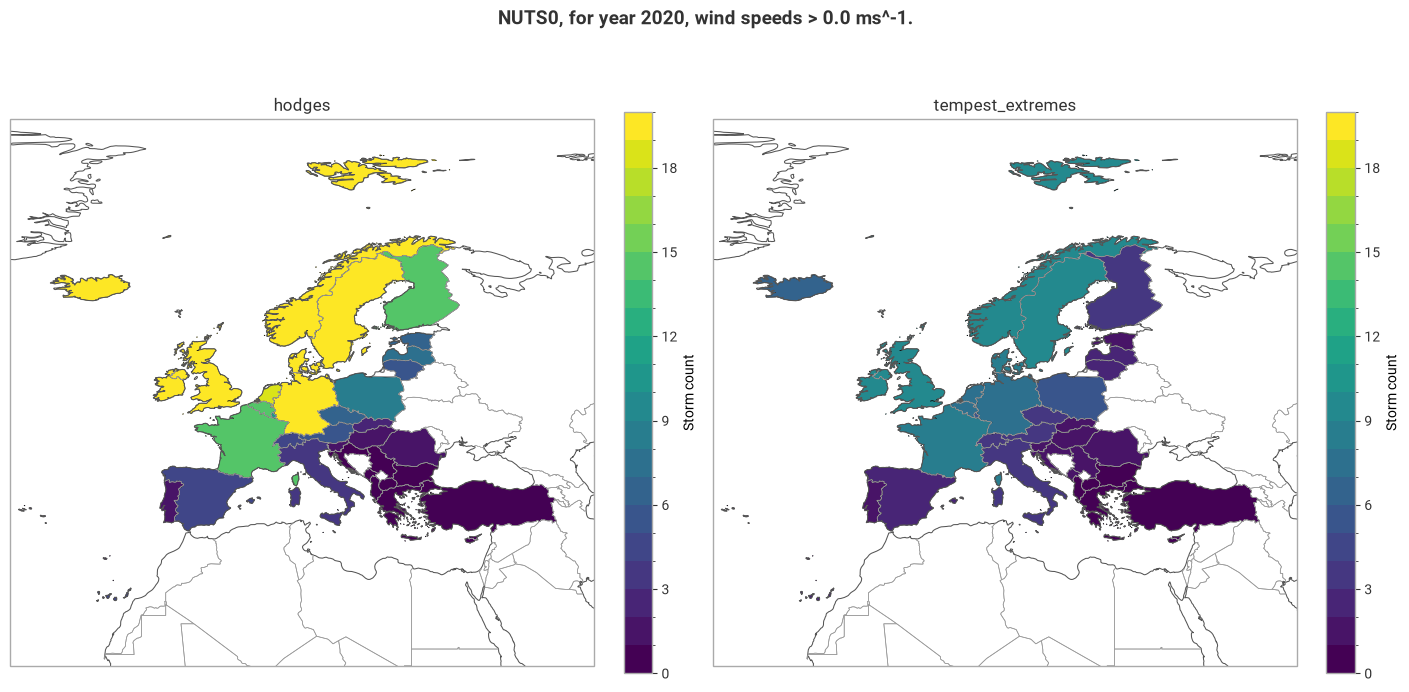

In [54]:
year = 2020
threshold = 0.0 
nuts_level = 0

fig = ekp.Figure(rows=1, columns=2, size=(14, 6))

map1 = fig.add_map(domain=DOMAIN, crs=ccrs.PlateCarree())

plot_storm_count_comparison(indic_data, algorithm = "hodges", year = year, threshold = threshold , nuts_level = nuts_level, cmap = "viridis",
                            chart=map1, show=False)

map2 = fig.add_map(domain=DOMAIN, crs=ccrs.PlateCarree())

plot_storm_count_comparison(indic_data, algorithm = "tempest_extremes", year = year, threshold = threshold , nuts_level = nuts_level, cmap = "viridis",
                            chart= map2, show=False)

fig.title(f"NUTS{nuts_level}, for year {year}, wind speeds > {threshold} ms^-1.")
fig.show()  

Picking a NUTS0 region such as the UK, we compare the yearly storm count across the entire time series between the two trackers.

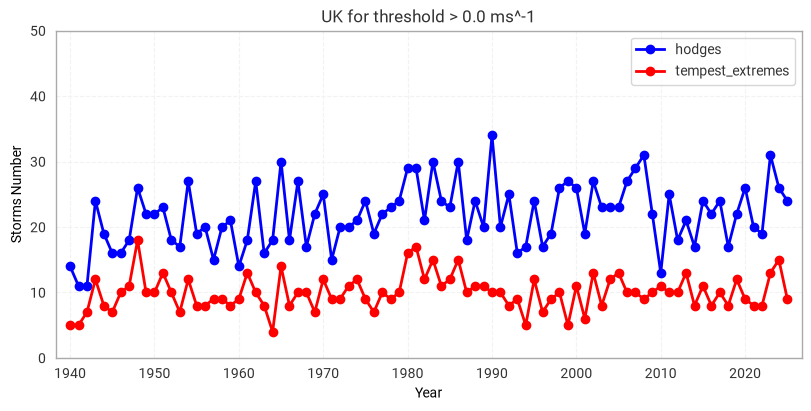

In [55]:
plot_region_var_time(indic_data, "UK", threshold = threshold, nuts_level = nuts_level )

To compare the sensitivity between the two trackers across the entire domain, we calculate the difference in the annual frequency of storms. This is done across every NUTS0 region, subtracting TempestExtremes from Hodges, and taking the spatial average across the entire domain.

In [56]:
data_mean_freq_NUTS = compute_mean_by_nuts(indic_data, "storms_number")

# --- Mean Hodges - Tempest per year ---
data_mean_freq_NUTS[0].loc[["difference"]].rename(
    columns={"storms_number": "Frequency / yr"}
)

Frequency / yr  NUTS_level
algorithm  threshold                            
difference 0.0              4.402263         0.0
           15.6             4.054683         0.0
           20.0             3.089881         0.0
           25.0             1.686047         0.0

We find that on average (spatially and temporally), the Hodges algorithm picks up 3-4 more ETCs yearly than the Tempest Extremes. 

In general, relative vorticity (Hodges) is better at capturing smaller spatial-scale processes compared to mean sea level pressure based tracking (TempestExtremes) [[Hodges et al., 2003](...)]. In the context of the windstorm dataset within EWS, this translates into a substantially larger number of events produced by Hodges compared to TempestExtremes. 

It is worth noting that as the threshold increase, the difference in ETCs picked up yearly decreases, with one possible explanation being that TempestExtremes is better at capturing larger spatial-scale processes that would be more typically associated with more intense ETCs.

Lastly, a time series of the yearly count, taking every NUTS0 region and spatially averaging over the entire domain is plotted. Four time series are plotted corresponding to storms with mean wind speeds above the stated thresholds. These thresholds roughly correspond to the [Beaufort scale](...), an empirical measure that relates wind speed to observed conditions at sea or on land.

Roughly, the given thresholds represent:

* Beaufort 0 — 0.0 m/s, calm or stronger.

* Beaufort 7 — 15.6 m/s, moderate gale or stronger.

* Beaufort 8 — 20.0 m/s, gale or stronger.

* Beaufort 10  — 25.0 m/s, storm or stronger.

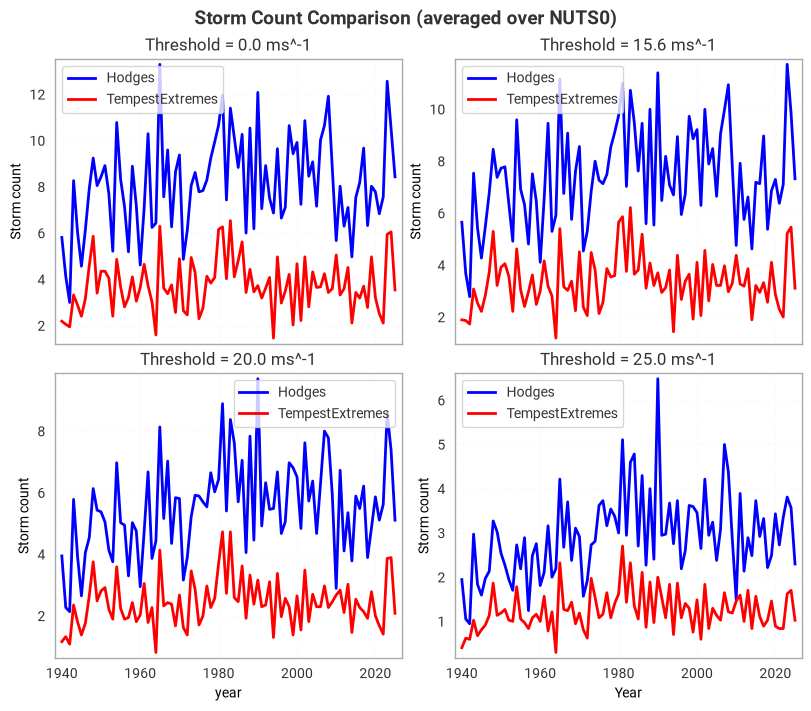

In [57]:
yearly_nuts_mean = compute_yearly_nuts_aggregation(indic_data, "storms_number", agg_func = "mean")

plot_storm_counts_time_comparison(yearly_nuts_mean)

We find that averaged across entire domain, the number of ETCs tracked by Hodges are greater than that of TempestExtremes, for each year.

#### Yearly Storm Count - from Tracks

Using the storm track dataset, the total number of storms identified by each algorithm across the entire domain was calculated by counting the number of unique storm_ids.

This information cannot be derived from the indicators dataset above, as that dataset records the number of storm occurrences exceeding a given threshold within specific regions. Summing these values would therefore result in double counting (or more), since the same storm may be recorded multiple times as it moves through different regions or exceeds thresholds repeatedly.  **[double-check this last part- how does it deem the storm as crossing the threshold?].**

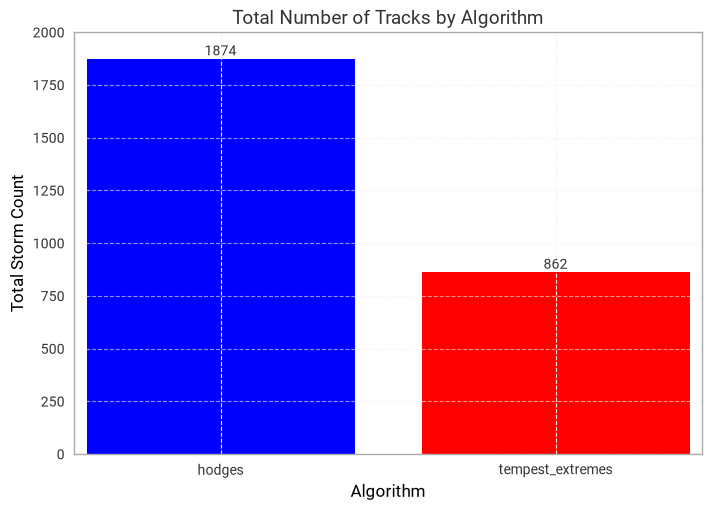

In [58]:
colors = ["blue", "red"]

def total_count_comparison(track_data, colors):
    # Colour mapping
    colors = ["blue", "red"]
    
    total_track_counts = (
        track_data.reset_index()
        .groupby("algorithm")["id"]
        .nunique()
    )
    
    plt.figure(figsize=(7, 5))
    
    plt.bar_label(plt.bar(total_track_counts.index, total_track_counts, color=colors)) # Adds number to the bar.
    
    # Labels and title
    plt.xlabel("Algorithm", fontsize=12)
    plt.ylabel("Total Storm Count", fontsize=12)
    plt.title("Total Number of Tracks by Algorithm", fontsize=14)
    
    # Improve tick appearance
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    
    plt.ylim([0, 2000])
    plt.show()

total_count_comparison(track_data, colors)

In total, more than 1000 storms are picked up by Hodges since 1940.

**Something about the annual storm count always being higher...**

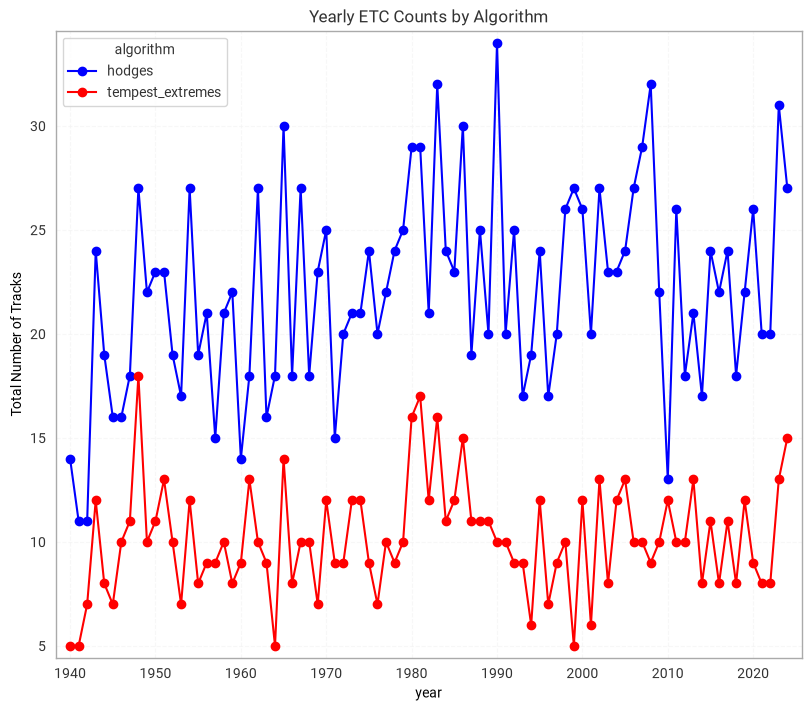

In [59]:
# Extract start and end timestmap for each ETC in each dataset
tracks_start_end = get_track_ends(track_data)


# Extract month by name from start_time
tracks_start_end["year"] = tracks_start_end["start_time"].dt.year

# Count number of tracks per month per algorithm
yearly_counts = (
    tracks_start_end
    .groupby(["algorithm", "year"])
    .size()
    .unstack(fill_value=0)
) 

yearly_counts.T.plot(marker="o", color=colors)

plt.ylabel("Total Number of Tracks")
plt.title("Yearly ETC Counts by Algorithm")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Next, the total number of storms tracked by their respective algorithms per month are counted. This is taken from the starting timestamp provided in the track dataset. 

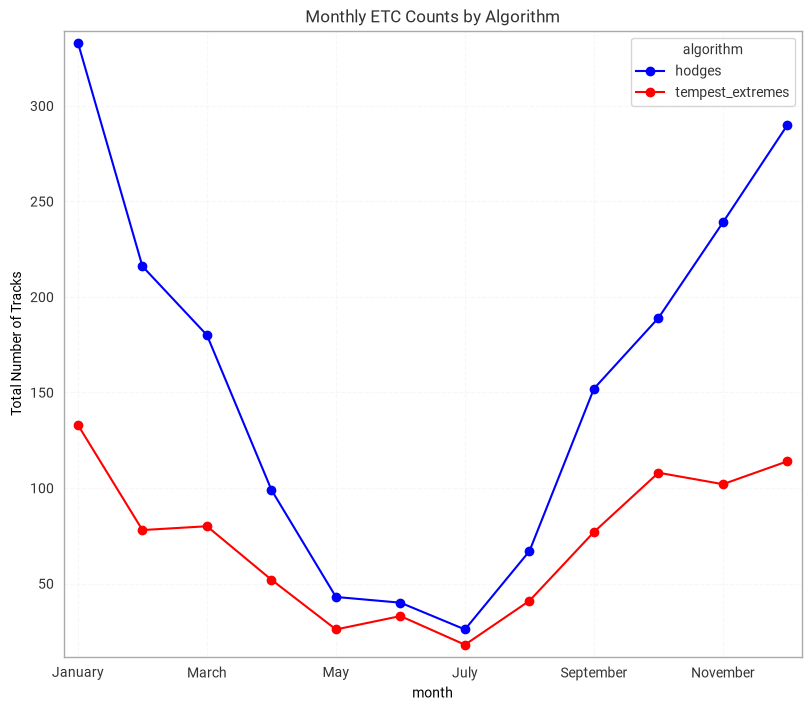

In [60]:
# Extract month by name from start_time
tracks_start_end["month"] = tracks_start_end["start_time"].dt.month_name()

# Count number of tracks per month per algorithm
monthly_counts = (
    tracks_start_end
    .groupby(["algorithm", "month"])
    .size()
    .unstack(fill_value=0)
) 

# Reorder as by default alphabetical!
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_counts = monthly_counts[month_order] # Reorder columns

monthly_counts.T.plot(marker="o", color=colors)

plt.ylabel("Total Number of Tracks")
plt.title("Monthly ETC Counts by Algorithm")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

There are 2-3x more ETCs in the Hodges algorithm than the TempestExtremes algorithmn in the winter months of December, January and February (DJF). However, the number of ETCs tracked between algorithms in June, July and August (JJA) are more in line with one another.

In [61]:
tempest_count = count_storms_per_month(track_data, "tempest_extremes") 
hodges_count = count_storms_per_month(track_data, "hodges")

results = {}

results["Algo Comparison"] = compute_fractions(hodges_count, tempest_count)

szn_fraction_data = {
    "Winter / Summer": [1/results["Algo Comparison"][2], 1/results["Algo Comparison"][3]]
}

track_index = ["Hodges", "TempestExtremes"]

df_szn_fraction = pd.DataFrame(szn_fraction_data, index=track_index)
df_szn_fraction.index.name = "Tracker"
df_szn_fraction.round(2)

,Winter / Summer
Tracker,
Hodges,6.54
TempestExtremes,3.90


 It is known that Winter ETCs tend to be more intense, and therefore easier to identify and track. Both tracking algorithms found 4-7x more ETCs in the Winter than the Summer, in agreement with Hoskins and Hodges (2002, 2005) and Ulbrich et al. (2009) [[Walker et al., 2020](https://doi.org/10.1002/wea.3861)].

In [62]:
tracker_fraction_data = {
    "Hodges / Tempest": [results["Algo Comparison"][0], results["Algo Comparison"][1]]
}

szn_fraction_index = ["Winter", "Summer"]

df_tracker_fraction = pd.DataFrame(tracker_fraction_data, index=szn_fraction_index)
df_tracker_fraction.index.name = "Season"
df_tracker_fraction.round(2)

,Hodges / Tempest
Season,
Winter,2.46
Summer,1.46


The inter-seasonality sensitivity between trackers is also compared. We find that Hodges is more sensitive than TempestExtremes in the Winter than the Summer, picking up 2.5x more ETCs in the Winter, and 1.5x more ETCs in the Summer. 

Whilst it is expected that Hodges is more sensitive than TempestExtremes across all seasons, it is interesting that the increased sensitivity of Hodges over TempestExtremes decreases in the Summer months (JJA) when compared to the Winter months (DJF). This suggests that the two tracking algorithms react different to the generally weaker heat lows in Summer.  

#### Sensitivity in matchups
In this section, we apply the track-to-track comparison method proposed by [Hodges et al. (2003)](...) to evaluate the correspondence between ETC tracks in both datasets.

Tracks are first identified by first finding ETC tracks identified by the Hodges algorithm that overlap in time with those identified by the TempestExtremes.

In [63]:
time_matches_only = match_by_time(track_data)

In [64]:
time_matches_only

,hodges_id,tempest_id,overlap_points,hodges_points,tempest_points,time_match,match
0,4,1,13,13,13,1.000000,True
1,8,4,14,14,15,0.965517,True
4,12,5,8,8,8,1.000000,True
5,16,6,25,25,28,0.943396,True
6,21,7,5,6,5,0.909091,True
...,...,...,...,...,...,...,...
1204,1867,857,18,24,19,0.837209,True
1205,1870,858,15,16,15,0.967742,True
1206,1871,859,7,7,7,1.000000,True
1207,1873,861,10,11,14,0.800000,True


If the number of points that overlap is greater than or equal to 60% of the number of points in the tracks, this is considered a possible good match in time.

For the tracks that satisfy the constraint in time, the mean separation of the points that overlap in time is calculated using the haversine distance, the shortest distance between two points on the surface of a sphere, given their latitudes and longitudes.

In [65]:
matches_only = match_by_mean_distance(track_data, time_matches_only)

If the mean separation between the points that overlap in time is less than 300 km, than a pair of matching tracks is detected. Since more than one track in a dataset may satisfy the temporal overlap condition with a track in another dataset, the one with the lowest mean distance is considered the matching track.

In [66]:
filtered_matches_only = matches_only[matches_only["distance"] < 300].dropna()
not_matched =  matches_only[matches_only["distance"] >= 300].dropna()

Track agreement is calculated as the percentage of mathcing tracks and the dataset with the lowest number of tracks. 

In [67]:
total_matches = filtered_matches_only["match"].count() # total number of matchups
lower_number_count = track_data.loc["tempest_extremes"].index.nunique() # total number of tracks in dataset with lower number (TE)
percent_matches = (total_matches / lower_number_count)*100 # Calculate percentage.
print(f"Percentage of matches between the Hodges and Tempest Extremes = {percent_matches:.2f}%")

Percentage of matches between the Hodges and Tempest Extremes = 74.36%


#### Monthly matchup count
Similar to the comparison of total monthly storm counts between the two algorithms, we examine whether there is any month-to-month variability in the number of matchups identified by each method.

Whilst both algorithms may identify the "same storm" with the above matchup methodology, the "same storm" may start earlier than the "same storm" in the other dataset. To address this discrepancy, we assign the matchup storm to a given month based on the first timestamp at which an overlap between the two datasets is identified.

In [68]:
matches_with_monthly_name = filtered_matches_only.reset_index().copy()

for count , (hodges_id, tempest_id) in enumerate(zip(filtered_matches_only["hodges_id"], filtered_matches_only["tempest_id"])):
    h_track = track_data.loc["hodges"].loc[hodges_id]["time"]
    te_track = track_data.loc["tempest_extremes"].loc[tempest_id]["time"]

    common_times = h_track[h_track.isin(te_track)]
    first_month = common_times.iloc[0].month_name()
    
    # Extract month by name from start_time
    matches_with_monthly_name.loc[count, "month"] = first_month

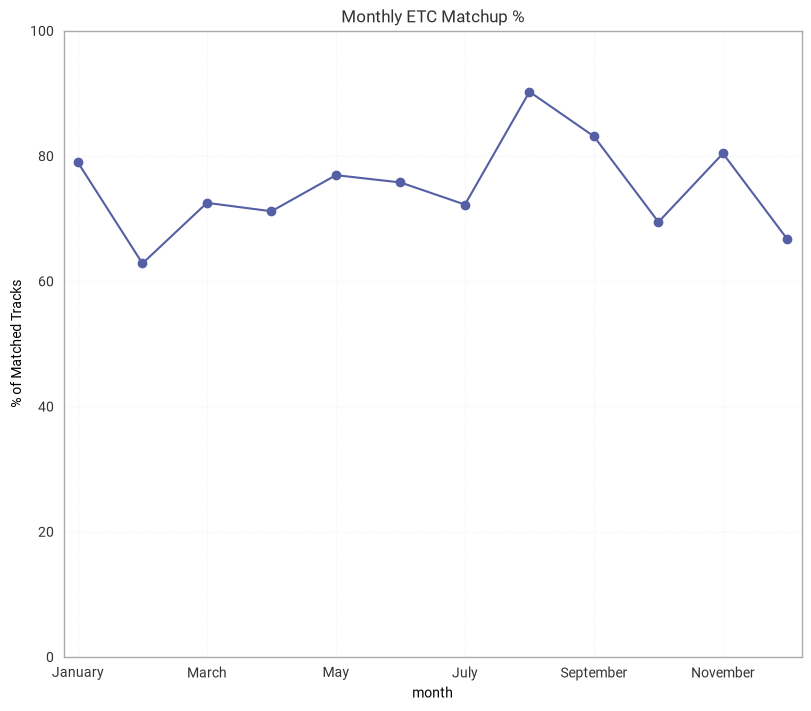

In [69]:
# Count number of tracks per month per algorithm
matched_monthly_counts = (
    matches_with_monthly_name
    .groupby(["month"])
    .size()
) 

matched_monthly_counts = matched_monthly_counts[month_order] # Reorder columns

fraction_matched_monthly = (matched_monthly_counts / monthly_counts.loc["tempest_extremes"])*100

fraction_matched_monthly.T.plot(marker="o")

plt.ylabel("% of Matched Tracks")
plt.title("Monthly ETC Matchup %")
plt.grid(True, linestyle="--", alpha=0.6)
plt.ylim([0, 100])
plt.show()

From the plot above, we find that the percentage matchup agreement shows high monthly variability, ranging from just over 60% in February, to 90% in August. **Do we want to answer why??**

#### Inter-seasonal matchup count variability
In the table below, we show the results of the track matchup between the Summer (JJA) and Winter (DJF). Shown are the number of cyclones for Summer (JJA, first column) and Winter (DJF, first row) and the track agreement between the two algorithms for summer (lower-left) and winter (top-right), with the values denoting a nominal percentage agreement, relative to the lower number of tracks produced by the two methods.

In [70]:
hodges_monthly_counts = monthly_counts.loc["hodges"]
tempest_monthly_counts = monthly_counts.loc["tempest_extremes"]


winter_months = ["December", "January", "February"]
summer_months = ["June", "July", "August"]

winter_matchup_count = matched_monthly_counts[winter_months].sum()
winter_tempest_count = tempest_monthly_counts[winter_months].sum()
winter_hodges_count = hodges_monthly_counts[winter_months].sum()

summer_matchup_count = matched_monthly_counts[summer_months].sum()
summer_tempest_count = tempest_monthly_counts[summer_months].sum()
summer_hodges_count = hodges_monthly_counts[summer_months].sum()


winter_matchup_frac = round((winter_matchup_count / winter_tempest_count)*100)
summer_matchup_frac = round((summer_matchup_count/ summer_tempest_count)*100)

In [71]:
matchup_table = pd.DataFrame(
    {
        "JJA (#)": ["×100", summer_hodges_count, summer_tempest_count],
        "Hodges (%)": [winter_hodges_count, 100, summer_matchup_frac],
        "Tempest (%)": [winter_tempest_count, winter_matchup_frac, 100],
    },
    index=["DJF (#)", "Hodges (%)", "Tempest (%)"]
)

matchup_table.index.name = "Method"

In [72]:
def style_table(val):
    if val == 100:
        return "background-color: #bfbfbf; font-weight: bold;"   # grey (diagonal)
    elif val == "×100":
        return "background-color: #d9d9d9;"  # lighter grey
    elif val in [winter_hodges_count, winter_tempest_count]:
        return "color: blue; background-color: #d9d9d9"  # blue
    elif val in [summer_hodges_count, summer_tempest_count]:
        return "color: red; background-color: #d9d9d9"  # red
    elif val in [summer_matchup_frac]:
        return "background-color: #F4D7CC"  # red
    elif val in [winter_matchup_frac]:
        return "background-color:  #D9E2F3"  # blue background
    else:
        return ""

styled = matchup_table.style.map(style_table)
styled

,JJA (#),Hodges (%),Tempest (%)
Method,,,
DJF (#),×100,839,325
Hodges (%),133,100,71
Tempest (%),92,82,100


The methods agree better for summer ETCs than for winter ETCs. This is surprising as ETCs tend to be more intense in the winter, therefore easier to detect.

#### Spatial density of ETC trajectories

In [141]:
grid_no_track = track_data.groupby(['algorithm', 'latitude','longitude']).size().reset_index().rename(columns={0:'track_count'})
hodges_grid = grid_no_track.loc[grid_no_track["algorithm"] == "hodges"]
tempest_grid = grid_no_track.loc[grid_no_track["algorithm"] == "tempest_extremes"]
total_no_tracks = track_data.groupby(['algorithm']).size()

In [142]:
hodges_grid["track_count"] = hodges_grid["track_count"] / (total_no_tracks["hodges"]* 1e-4)
tempest_grid["track_count"] = tempest_grid["track_count"] / (total_no_tracks["tempest_extremes"]* 1e-4) 

/home/eg6/c3s2-eqc-quality-assessment/.venv/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)


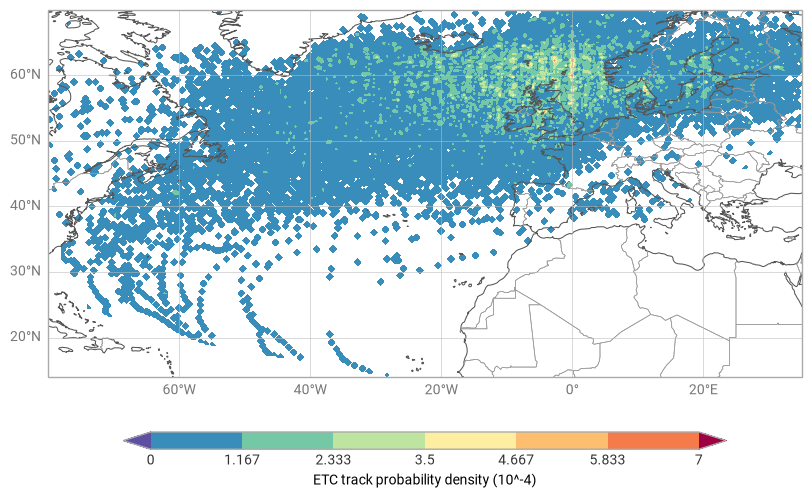

In [184]:
vmin = 0
vmax = 7

LEVELS = np.linspace(vmin, vmax, 7)  # 15 smooth levels

STYLE = ekp.styles.Style(
    levels=LEVELS,
    extend="both",
    colors="Spectral_r",
)

chart = ekp.Map()

chart.contourf(
    z=hodges_grid.track_count.values,
    x=hodges_grid.longitude.values,
    y=hodges_grid.latitude.values,
    style=STYLE,
    linewidths=0,
    interpolate=dict(distance_threshold="auto"),
)

chart.coastlines()
chart.borders()
chart.gridlines()

chart.legend(label="ETC track probability density (10^-4)")

chart.show()

/home/eg6/c3s2-eqc-quality-assessment/.venv/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: linewidths is ignored by contourf
  result = super().contourf(*args, **kwargs)


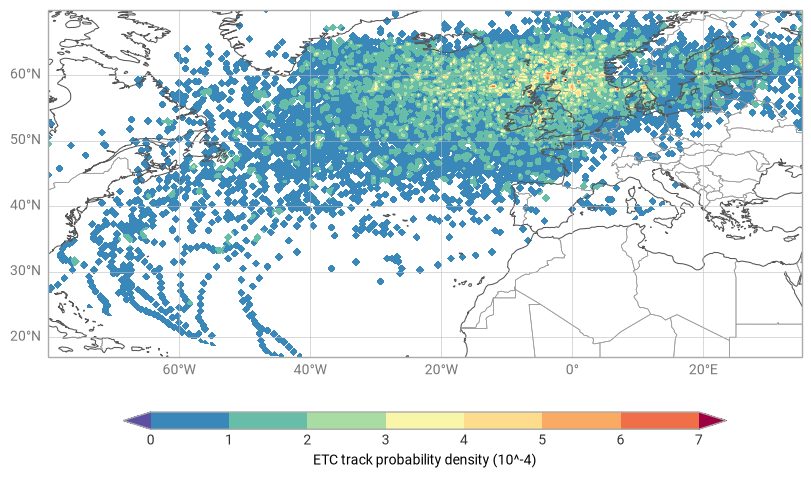

In [183]:
vmin = 0
vmax = 7

LEVELS = np.linspace(vmin, vmax, 8)  # 15 smooth levels

STYLE = ekp.styles.Style(
    levels=LEVELS,
    extend="both",
    colors="Spectral_r",
)

chart = ekp.Map()

chart.contourf(
    z=tempest_grid.track_count.values,
    x=tempest_grid.longitude.values,
    y=tempest_grid.latitude.values,
    style=STYLE,
    linewidths=0,
    interpolate=dict(distance_threshold="auto"),
)

chart.coastlines()
chart.borders()
chart.gridlines()

chart.legend(label="ETC track probability density (10^-4)")

chart.show()

(section-duration)=
### 4. Duration

#### Quantiles for duration of storms 

In this section, we look at the statistics of the lifecycles of the detected cyclones in both datasets without matchups, and between the matchup pairs. The "duration" of a detected ETCs is defined as the difference in the final and first timestamp.

The computed statistics are the mean, median, standard deviation along with the 25th (q25) percentile and 75th (q75) percentile. 

In [73]:
tracks_start_end = get_track_ends(track_data)

stats = track_stats(tracks_start_end)

In [74]:
stats["ALL"].round(2)

,mean,median,std,q25,q75
algorithm,,,,,
hodges,3.00,2.5,1.79,1.75,3.75
tempest_extremes,3.75,3.0,2.39,2.25,4.50


On average we find that the average lifetime for TempestExtremes is larger than that of Hodges, however there is larger variation (high standard deviation and IQR) in each to definitively say.

In [75]:
stats["DJF"].round(2)

,mean,median,std,q25,q75
algorithm,,,,,
hodges,2.83,2.50,1.61,1.75,3.5
tempest_extremes,3.78,3.25,2.23,2.25,4.5


This is also seen in the winter months, with the lifetime decreasing on average for Hodges whilst remaining more or less the same for Tempest. Quite a high amount of variation to definitely say though...

In [76]:
stats["JJA"].round(2)

,mean,median,std,q25,q75
algorithm,,,,,
hodges,3.14,2.5,2.19,1.75,3.5
tempest_extremes,3.51,2.5,3.10,1.75,4.0


Hard to definitely say again because of high variation.

#### Lifetime distribution
Next, we show the lifetime distribution of the two algorithms with a probability density function, binned at a 12 hour resolution (2x the temporal resolution).

In [77]:
tracks_start_end = get_track_ends(track_data)
hodges_track_start_end = tracks_start_end[tracks_start_end["algorithm"] == "hodges"]
tempest_track_start_end = tracks_start_end[tracks_start_end["algorithm"] == "tempest_extremes"]

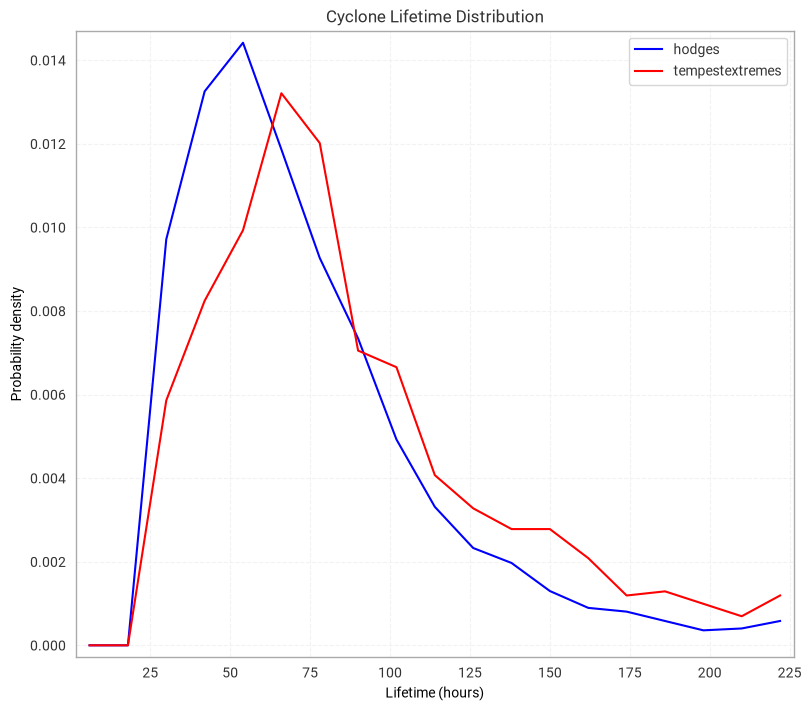

In [92]:
plot_lifetime_distribution(
    data=[hodges_track_start_end, tempest_track_start_end],
    labels=["hodges", "tempestextremes"],
    colors = colors,
    bins=np.arange(0, 240, 12),
)

* Spread in TempestExtremes is larger.
* Peak of TempestExtremes longer.
* TempestExtremes finds ETCs that last longer.
* Hodges finds ETCs that are shorter.

#### Lifetime distribution (matchups only)
It is interesting to compare the distribution between each ETC in a matchup pair for the "same storm". We look at the probability density function, again binning at a 12 hour resolution (2x temporal resolution).

In [80]:
# Separate start / end points based on algorithm.
h_track = tracks_start_end[tracks_start_end["algorithm"] == "hodges"]
te_track = tracks_start_end[tracks_start_end["algorithm"] == "tempest_extremes"]

# Filter only hodges id's that match.
h_ids_to_keep = filtered_matches_only["hodges_id"] 

h_filtered_tracks = h_track[
    h_track["id"].isin(h_ids_to_keep)
]

# Filter only tempest id's that match.
te_ids_to_keep = filtered_matches_only["tempest_id"]

te_filtered_tracks = te_track[
    te_track["id"].isin(te_ids_to_keep)
]

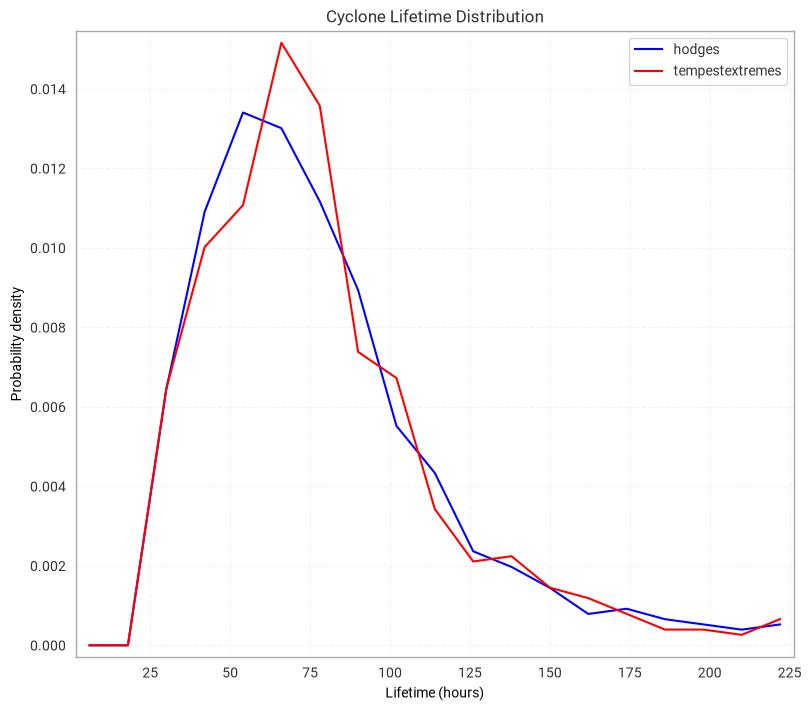

In [93]:
# Plot lifetime distribution between match ups.
plot_lifetime_distribution(
    data=[h_filtered_tracks, te_filtered_tracks],
    labels=["hodges", "tempestextremes"],
    colors = colors,
    bins=np.arange(0, 240, 12),
)

* Peak for Hodges remains shifted earlier.
* Distribution of shorter timescale ETCs almost identical.
* Distribution of longer timescale ETCs almost identical, except for some variation.

#### Quantiles for duration of storms (matchups only)

In [ ]:
# Separate start / end points based on algorithm.
h_track = tracks_start_end[tracks_start_end["algorithm"] == "hodges"]
te_track = tracks_start_end[tracks_start_end["algorithm"] == "tempest_extremes"]

# Filter only hodges id's that match.
h_ids_to_keep = filtered_matches_only["hodges_id"] 

h_filtered_tracks = h_track[
    h_track["id"].isin(h_ids_to_keep)
]

# Filter only tempest id's that match.
te_ids_to_keep = filtered_matches_only["tempest_id"]

te_filtered_tracks = te_track[
    te_track["id"].isin(te_ids_to_keep)
]

In [82]:
(te_filtered_tracks["end_time"] - te_filtered_tracks["start_time"]).mean()

Timedelta('3 days 06:15:43.525741')

In [83]:
(h_filtered_tracks["end_time"] - h_filtered_tracks["start_time"]).mean()

Timedelta('3 days 05:03:50.265210')

**Not sure what information we can obtain from above**

(section-intensity)=
### 5. Intensity

Count how many deep / weak ETCs there are based on MSLP at tracker.

#### Mean wind gust - from Indicators

In [ ]:
data_mean_wind_NUTS = compute_mean_by_nuts(indic_data, "mean_wind_gust")

# --- Mean Hodges - Tempest per year ---
data_mean_wind_NUTS[0].loc[["difference"]]

In [ ]:
threshold = 0.0

nuts_percentage = computer_percentage_greater_eq(indic_data, nuts_gdf, value_column = "mean_wind_gust", threshold = threshold)

plot_nuts_greater_eq_than_spatial(nuts_percentage[0],
                   title = f"% Years with Δ Mean Wind Gust(Wind Gust > Threshold = {threshold}) (H − TE) >= 0",)

In [ ]:
threshold = 25.0

nuts_percentage = computer_percentage_greater_eq(indic_data, nuts_gdf, value_column = "mean_wind_gust", threshold = threshold)

plot_nuts_greater_eq_than_spatial(nuts_percentage[0],
                   title = f"% Years with Δ Mean Wind Gust(Wind Gust > Threshold = {threshold}) (H − TE) >= 0",)

#### Normalised Storm Severity Index (NSSI) - from Indicators

In [ ]:
data_nssi_NUTS = compute_mean_by_nuts(indic_data, "normalised_ssi")

# --- Mean Hodges - Tempest per year ---
data_nssi_NUTS[0].loc[["difference"]]

In [ ]:
threshold = 0.0

nuts_percentage = computer_percentage_greater_eq(indic_data, nuts_gdf, value_column = "normalised_ssi", threshold = threshold)

plot_nuts_greater_eq_than_spatial(nuts_percentage[0],
                   title = f"% Years with Δ NSSI(Wind Gust > Threshold = {threshold}) (H − TE) >= 0",)

(section-matchups)=
### 6. Matchups

#### Comparison between matchups

In [ ]:
h_start_end_track = tracks_start_end[tracks_start_end["algorithm"] == "hodges"]
te_start_end__track = tracks_start_end[tracks_start_end["algorithm"] == "tempest_extremes"]
h_track = track_data.loc["hodges"]
te_track = track_data.loc["tempest_extremes"]

comparison = []
for hodges_id, tempest_id in zip(filtered_matches_only["hodges_id"], filtered_matches_only["tempest_id"]):

    h = h_start_end_track[h_start_end_track["id"] == hodges_id].iloc[0]
    te = te_start_end__track[te_start_end__track["id"] == tempest_id].iloc[0]

    comparison.append({
    
                # time differences (Timedelta)
                "start_time_diff": h["start_time"] - te["start_time"],
                "end_time_diff": h["end_time"] - te["end_time"],
    
                # spatial differences (just raw differences)
                "start_lat_diff": h["start_lat"] - te["start_lat"],
                "start_lon_diff": h["start_lon"] - te["start_lon"],
                "end_lat_diff": h["end_lat"] - te["end_lat"],
                "end_lon_diff": h["end_lon"] - te["end_lon"],

                # intensity differences (just raw max wind speed along TOTAL track)
                "hodges_mean_max_fg10": h_track["fg10"].loc[hodges_id].max(),
                "tempest_mean_max_fg10": te_track["fg10"].loc[tempest_id].max(),
            })
comparison_df = pd.DataFrame(comparison)

In [ ]:
comparison_df.mean()

Mean max wind gust for Hodges

In [ ]:
h_track = track_data.loc["hodges"]
te_track = track_data.loc["tempest_extremes"]

In [ ]:
h_mean_of_max = h_track.groupby(level=0)['fg10'].max().mean()
h_mean_of_max

Mean max wind gust for Tempest

In [ ]:
te_mean_of_max = te_track.groupby(level=0)['fg10'].max().mean()
te_mean_of_max

#### Visualising matchups

All matchups that satisfy 60%  timestamp overlap and mean distance is less than 300km for overlapping points.

In [ ]:
for hodges_id, tempest_id in zip(filtered_matches_only["hodges_id"], filtered_matches_only["tempest_id"]):
    plot_tracks(track_data, hodges_id, tempest_id) # plot each matchup with MSLP at start time for earliest storm laid on top.

All matchups that satisfy 60%  timestamp overlap but do not satisfy mean distance is less than 300km for overlapping points.

In [ ]:
for hodges_id, tempest_id in zip(filtered_not_matched["hodges_id"], filtered_not_matched["tempest_id"]):
    plot_tracks(track_data, hodges_id, tempest_id) # plot each matchup with MSLP at start time for earliest storm laid on top.

## ℹ️ If you want to know more

### Key resources

Code libraries used:
* [GeoPandas](https://geopandas.org/en/stable/)
* [earthkit](https://github.com/ecmwf/earthkit)
  * [earthkit-data](https://github.com/ecmwf/earthkit-data)
  * [earthkit-plots](https://github.com/ecmwf/earthkit-plots)

### References
